# TP1 — Pipeline básico para construcción de modelos PINN
## Caso de estudio: Reconstrucción del campo de flujo en una cavidad cuadrada

**Redes Neuronales Informadas por Física** — Especialización en Inteligencia Artificial (CEIA-FIUBA)
3er bimestre 2026

**Nombre:** Julia Stephania Maldonado Gomez

---

### Supuestos adoptados

El enunciado del TP1 hace referencia al *"sistema de ecuaciones del enunciado"* y a las *"PDE de gobierno"*
sin especificarlas explícitamente en el documento entregado (se asume que fueron presentadas en clase o en
material complementario no disponible al momento de resolver este trabajo). En base al dataset ground-truth
provisto (`velocity.mat`, `pressure.mat`) se adoptan los siguientes supuestos, dejados aquí documentados
explícitamente:

- **Problema físico:** flujo *lid-driven cavity* (cavidad con tapa deslizante), 2D, estacionario, incompresible.
- **Dominio:** cuadrado unitario $(x,y) \in [0,1]\times[0,1]$ (confirmado por el rango de coordenadas del dataset).
- **Condiciones de borde** (confirmadas inspeccionando los valores de borde del dataset):
  - Tapa superior ($y=1$): $u=1$, $v=0$ (velocidad adimensional de arrastre).
  - Paredes izquierda, derecha e inferior: $u=0$, $v=0$ (no-slip).
- **Número de Reynolds:** $Re = 100$ (valor estándar de este problema clásico, no especificado en el dataset
  ni en el enunciado; se documenta como supuesto explícito).
- **Ecuaciones de gobierno:** Navier-Stokes incompresible, adimensional, estado estacionario:

$$u\,u_x + v\,u_y = -p_x + \frac{1}{Re}\left(u_{xx}+u_{yy}\right)$$
$$u\,v_x + v\,v_y = -p_y + \frac{1}{Re}\left(v_{xx}+v_{yy}\right)$$
$$u_x + v_y = 0 \quad \text{(continuidad)}$$

- **Indeterminación de presión:** este sistema (continuidad + momento) no fija un nivel de referencia absoluto
  para $p$: si $p(x,y)$ es solución, $p(x,y)+c$ también lo es para cualquier constante $c$, ya que las ecuaciones
  solo involucran gradientes de presión. Como no se emplean datos rotulados durante el entrenamiento (según
  pide el enunciado), el modelo aprenderá el campo de presión a menos de una constante aditiva arbitraria.
  Esto se discute y se corrige *a posteriori* (solo a fines de comparación/visualización, no de entrenamiento)
  en la sección de validación.


## 0. Setup e importación de librerías

In [13]:
import numpy as np
import torch
import torch.nn as nn
import scipy.io as sio
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

plt.rcParams['figure.dpi'] = 100


Device: cpu


## 0.1 Carga del dataset ground-truth

Se cargan los archivos `velocity.mat` (contiene $x,y,z,u,v,w$) y `pressure.mat` (contiene $x,y,z,p$)
provistos por la cátedra. Ambos comparten la misma grilla de coordenadas, por lo que se combinan en un
único array. Notar que la grilla no es un mallado regular completo, sino un patrón tipo "tablero de ajedrez"
sobre una grilla estructurada de 201×201 puntos (Δx=Δy=0.005), con 20201 puntos totales.

In [14]:
data_v = sio.loadmat('velocity.mat')
data_p = sio.loadmat('pressure.mat')

x_gt = data_v['x'].flatten()
y_gt = data_v['y'].flatten()
u_gt = data_v['u'].flatten()
v_gt = data_v['v'].flatten()
p_gt = data_p['p'].flatten()

coords_match = np.allclose(x_gt, data_p['x'].flatten()) and np.allclose(y_gt, data_p['y'].flatten())
assert coords_match, "Las coordenadas de velocity.mat y pressure.mat no coinciden"

N_gt = len(x_gt)
print(f'Puntos ground-truth: {N_gt}')
print(f'Dominio: x in [{x_gt.min():.2f}, {x_gt.max():.2f}], y in [{y_gt.min():.2f}, {y_gt.max():.2f}]')
print(f'u in [{u_gt.min():.3f}, {u_gt.max():.3f}]  (u=1 en la tapa -> confirma lid-driven cavity)')
print(f'v in [{v_gt.min():.3f}, {v_gt.max():.3f}]')
print(f'p in [{p_gt.min():.3f}, {p_gt.max():.3f}]')

# KD-Tree para búsquedas de vecino más cercano (se usa más adelante para el dataset rotulado)
gt_tree = cKDTree(np.column_stack([x_gt, y_gt]))


Puntos ground-truth: 20201
Dominio: x in [0.00, 1.00], y in [0.00, 1.00]
u in [-0.239, 1.000]  (u=1 en la tapa -> confirma lid-driven cavity)
v in [-0.525, 0.304]
p in [-4.633, 5.734]


## 1. Datasets de puntos de colocación

### 1.1 Definición de subconjuntos de puntos de colocación

Siguiendo la geometría del problema (cuadrado $[0,1]^2$) y los términos de la función de pérdida, se definen
dos subconjuntos de puntos de colocación:

- **$\Omega_{pde}$** ($N_{pde}=1000$ puntos): puntos en el **interior** del dominio, donde se impone el
  residuo de las PDE de gobierno (momento en x, momento en y, continuidad). Se muestrean con estrategia
  aleatoria uniforme en $(0,1)\times(0,1)$, **excluyendo estrictamente las fronteras** (ver discusión en 1.4).

- **$\Omega_{bc}$** ($N_{bc}=100$ puntos): puntos sobre las **4 fronteras físicas** del dominio (tapa,
  paredes izquierda, derecha e inferior), donde se impone el residuo de condición de borde. Se reparten
  aleatoriamente entre las 4 paredes (25 puntos por pared) y dentro de cada pared se muestrea la coordenada
  libre de forma aleatoria uniforme.

In [15]:
N_pde = 1000
N_bc = 100

# --- Subconjunto PDE: interior estricto del dominio (0,1)x(0,1) ---
# Se excluyen los bordes (ver discusión punto 1.4)
eps = 1e-4
x_pde = np.random.uniform(eps, 1 - eps, size=(N_pde, 1))
y_pde = np.random.uniform(eps, 1 - eps, size=(N_pde, 1))

# --- Subconjunto BC: 4 paredes, N_bc/4 puntos por pared, muestreo aleatorio ---
n_wall = N_bc // 4

# Tapa superior (y=1): u=1, v=0
x_top = np.random.uniform(0, 1, size=(n_wall, 1))
y_top = np.ones((n_wall, 1))
u_top = np.ones((n_wall, 1))
v_top = np.zeros((n_wall, 1))

# Pared inferior (y=0): u=0, v=0
x_bot = np.random.uniform(0, 1, size=(n_wall, 1))
y_bot = np.zeros((n_wall, 1))
u_bot = np.zeros((n_wall, 1))
v_bot = np.zeros((n_wall, 1))

# Pared izquierda (x=0): u=0, v=0
x_left = np.zeros((n_wall, 1))
y_left = np.random.uniform(0, 1, size=(n_wall, 1))
u_left = np.zeros((n_wall, 1))
v_left = np.zeros((n_wall, 1))

# Pared derecha (x=1): u=0, v=0
x_right = np.ones((n_wall, 1))
y_right = np.random.uniform(0, 1, size=(n_wall, 1))
u_right = np.zeros((n_wall, 1))
v_right = np.zeros((n_wall, 1))

x_bc = np.vstack([x_top, x_bot, x_left, x_right])
y_bc = np.vstack([y_top, y_bot, y_left, y_right])
u_bc = np.vstack([u_top, u_bot, u_left, u_right])
v_bc = np.vstack([v_top, v_bot, v_left, v_right])
wall_id = np.array(['top']*n_wall + ['bottom']*n_wall + ['left']*n_wall + ['right']*n_wall)

print(f'Puntos PDE (interior): {x_pde.shape[0]}')
print(f'Puntos BC (frontera):  {x_bc.shape[0]}  ({n_wall} por pared)')


Puntos PDE (interior): 1000
Puntos BC (frontera):  100  (25 por pared)


### 1.2 Gráfico de los puntos de colocación

Se grafican ambos subconjuntos con un color distinto según a cuál pertenecen.

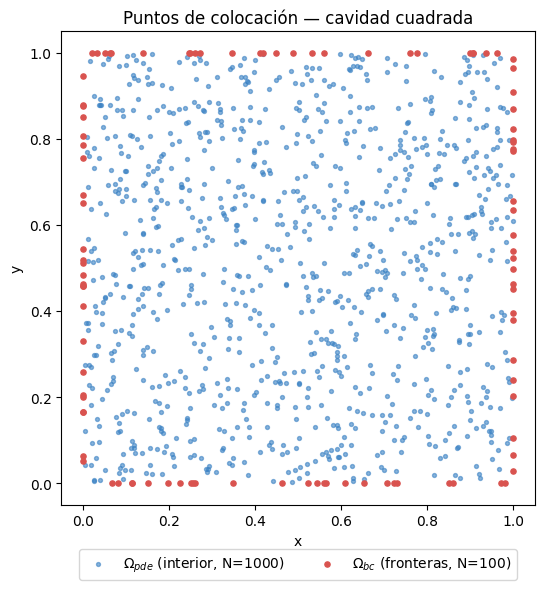

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_pde, y_pde, s=8, c='#3B82C4', label=f'$\\Omega_{{pde}}$ (interior, N={N_pde})', alpha=0.6)
ax.scatter(x_bc, y_bc, s=14, c='#D9534F', label=f'$\\Omega_{{bc}}$ (fronteras, N={N_bc})', zorder=3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Puntos de colocación — cavidad cuadrada')
ax.set_aspect('equal')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
plt.tight_layout()
plt.savefig('fig_collocation_points.png', dpi=120, bbox_inches='tight')
plt.show()


### 1.3 Dataset de datos rotulados ($N_{data}=10$)

Se seleccionan $N_{data}=10$ puntos $(x,y)$ del dominio de forma aleatoria, y se les asignan como *labels*
las mediciones de presión y velocidad correspondientes, obtenidas por vecino más cercano sobre la grilla
ground-truth (emulando así mediciones puntuales tipo sensores, tal como lo describe el enunciado).

**¿Qué sugiere la estructura de este dataset respecto de los subconjuntos de colocación, en relación con
los labels?**

La diferencia estructural es clave: los subconjuntos $\Omega_{pde}$ y $\Omega_{bc}$ son *datasets de entrada
pura* — solo contienen coordenadas $(x,y)$ (y, en el caso de $\Omega_{bc}$, el valor conocido de la condición
de borde, que no es un "label" en sentido supervisado sino una restricción algebraica). No contienen un
valor objetivo de $p$, $u$, $v$ contra el cual comparar directamente la salida de la red: su "supervisión"
es indirecta, a través del residuo de la PDE (que debería tender a cero), no a través de un error respecto
a un valor medido.

En cambio, el dataset $\mathcal{D}_{data}$ tiene la estructura clásica de un dataset **supervisado**:
pares $(X, Y) = ((x_i,y_i),\,(p_i,u_i,v_i))$, con *labels* explícitos. Esto sugiere que este subconjunto
habilita agregar un **término de pérdida adicional tipo regresión** ($\mathcal{L}_{data}$, por ejemplo
error cuadrático medio entre la predicción del modelo y el label medido) a la función de pérdida total,
complementando —y no reemplazando— los residuos físicos. Es el mecanismo que permite pasar de un esquema
PINN puramente basado en física a uno *data-informed*, combinando datos escasos con las restricciones del
modelo físico. En este TP1 se construye el dataset pero, siguiendo lo pedido en la sección de implementación
del PINN *vanilla*, **no se lo utiliza durante el entrenamiento** (el modelo se resuelve sin datos rotulados).

In [17]:
N_data = 10
x_data = np.random.uniform(0, 1, size=(N_data, 1))
y_data = np.random.uniform(0, 1, size=(N_data, 1))

# Vecino más cercano en la grilla ground-truth para asignar los labels medidos
_, idx_nn = gt_tree.query(np.column_stack([x_data.flatten(), y_data.flatten()]))
p_data = p_gt[idx_nn].reshape(-1, 1)
u_data = u_gt[idx_nn].reshape(-1, 1)
v_data = v_gt[idx_nn].reshape(-1, 1)

# Snap de las coordenadas a las del vecino más cercano (para que el label sea consistente con la coordenada)
x_data = x_gt[idx_nn].reshape(-1, 1)
y_data = y_gt[idx_nn].reshape(-1, 1)

print('Dataset rotulado (N_data=10):')
for i in range(N_data):
    print(f'  ({x_data[i,0]:.3f}, {y_data[i,0]:.3f})  ->  p={p_data[i,0]:.3f}, u={u_data[i,0]:.3f}, v={v_data[i,0]:.3f}')


Dataset rotulado (N_data=10):
  (0.915, 0.145)  ->  p=0.003, u=-0.004, v=-0.006
  (0.535, 0.205)  ->  p=0.002, u=-0.117, v=-0.009
  (0.155, 0.185)  ->  p=-0.000, u=-0.027, v=0.028
  (0.695, 0.895)  ->  p=-0.058, u=0.427, v=-0.035
  (0.795, 0.655)  ->  p=-0.032, u=-0.184, v=-0.348
  (0.315, 0.155)  ->  p=-0.000, u=-0.065, v=0.021
  (0.860, 0.440)  ->  p=-0.001, u=-0.080, v=-0.167
  (0.905, 0.615)  ->  p=-0.000, u=-0.085, v=-0.317
  (0.275, 0.085)  ->  p=-0.001, u=-0.032, v=0.008
  (0.985, 0.885)  ->  p=0.266, u=-0.011, v=-0.248


### 1.4 Para pensar: ¿el subconjunto PDE debería contener puntos sobre las fronteras físicas?

**No.** El subconjunto $\Omega_{pde}$ debería restringirse al interior abierto del dominio, por dos razones
principales:

1. **Redundancia / posible conflicto de gradientes:** los puntos de frontera ya están cubiertos por su
   propio residuo, $r_{bc}$, que impone directamente las condiciones de Dirichlet conocidas ($u,v$
   prescriptos). Si esos mismos puntos también contribuyeran al residuo de PDE ($r_{pde}$), se estarían
   imponiendo dos objetivos distintos sobre el mismo punto durante la optimización (uno algebraico exacto,
   otro diferencial), lo que puede generar gradientes contrapuestos y ralentizar/desestabilizar la
   convergencia, sin aportar información adicional relevante.

2. **Practicidad del cómputo de derivadas por autodiferenciación:** si bien físicamente la PDE se cumple
   también en el borde (las ecuaciones de Navier-Stokes son válidas en todo el dominio cerrado), en la
   práctica no hay necesidad de forzar explícitamente el residuo diferencial ahí porque la condición de
   borde (más fuerte, tipo Dirichlet) ya restringe completamente el valor de $u$ y $v$ en esos puntos.

En la implementación de este TP, el muestreo de $\Omega_{pde}$ se realizó explícitamente sobre el intervalo
abierto $(\epsilon, 1-\epsilon)$ para garantizar esta separación.

## 2. Implementación de esquema *vanilla* PINN

### 2.1 Arquitectura de la red

- **Entradas:** 2 (variables independientes $x$, $y$).
- **Salidas:** 3 (variables dependientes $p$, $u$, $v$), calculadas de forma **directa** (no se usa función
  de corriente ni splitting; la red predice las 3 salidas simultáneamente en su capa final).
- **Profundidad / ancho:** 5 capas ocultas de 40 neuronas cada una — tamaño moderado, elegido para lograr
  un buen equilibrio expresividad/tiempo de entrenamiento en CPU.
- **Activación:** $\tanh$ (activación estándar en PINNs por ser infinitamente diferenciable, requisito clave
  ya que se necesitan derivadas de 2do orden vía autodiferenciación).
- **Inicialización:** Xavier normal para los pesos, ceros para los sesgos.

In [18]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            modules.append(linear)
            modules.append(nn.Tanh())
        # Capa de salida (sin activación)
        linear_out = nn.Linear(layers[-2], layers[-1])
        nn.init.xavier_normal_(linear_out.weight)
        nn.init.zeros_(linear_out.bias)
        modules.append(linear_out)
        self.net = nn.Sequential(*modules)

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        out = self.net(inp)
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]
        return u, v, p


layers = [2, 40, 40, 40, 40, 40, 3]
model = PINN(layers).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParámetros entrenables: {n_params}')


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=40, bias=True)
    (9): Tanh()
    (10): Linear(in_features=40, out_features=3, bias=True)
  )
)

Parámetros entrenables: 6803


### 2.2 Rutinas de residuos (autodiferenciación)

Se calculan las derivadas de $u$, $v$, $p$ respecto de $x$ e $y$ mediante `torch.autograd.grad` con
`create_graph=True` (necesario porque luego se retropropaga a través de estas derivadas para actualizar
los pesos de la red). Con $Re=100$:

$$r_{u} = u\,u_x + v\,u_y + p_x - \frac{1}{Re}(u_{xx}+u_{yy})$$
$$r_{v} = u\,v_x + v\,v_y + p_y - \frac{1}{Re}(v_{xx}+v_{yy})$$
$$r_{cont} = u_x + v_y$$

In [19]:
Re = 100.0

def pde_residuals(model, x, y, Re=Re):
    u, v, p = model(x, y)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    r_u = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    r_v = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)
    r_cont = u_x + v_y
    return r_u, r_v, r_cont


### 2.3 Optimizador, hiperparámetros y tensores de entrenamiento

- **Optimizador:** Adam, `lr=1e-3`, `weight_decay=1e-5` (regularización L2 leve).
- **Scheduler:** decaimiento exponencial suave de la tasa de aprendizaje, para estabilizar la convergencia
  en las últimas etapas del entrenamiento.
- **Pesos de la función de pérdida:** $w_{pde}=1$, $w_{bc}=10$. Se pondera más fuerte la condición de borde
  porque, en la práctica, es común que el residuo de PDE "gane" la optimización a costa de no satisfacer bien
  las condiciones de contorno (fenómeno bien documentado en la literatura de PINNs vanilla), especialmente
  relevante en este problema porque $N_{bc} \ll N_{pde}$.
- **Epochs:** 8000, con *full-batch* (todos los puntos de colocación en cada paso, dado el tamaño reducido
  del dataset).

In [20]:
# Tensores de entrenamiento (requires_grad=True en x,y para poder derivar)
x_pde_t = torch.tensor(x_pde, dtype=torch.float32, requires_grad=True, device=device)
y_pde_t = torch.tensor(y_pde, dtype=torch.float32, requires_grad=True, device=device)

x_bc_t = torch.tensor(x_bc, dtype=torch.float32, device=device)
y_bc_t = torch.tensor(y_bc, dtype=torch.float32, device=device)
u_bc_t = torch.tensor(u_bc, dtype=torch.float32, device=device)
v_bc_t = torch.tensor(v_bc, dtype=torch.float32, device=device)

EPOCHS = 8000
LOG_EVERY = 500
W_PDE = 1.0
W_BC = 10.0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9997)

history = {'total': [], 'pde': [], 'bc': [], 'mom_u': [], 'mom_v': [], 'cont': []}


### 2.4 Loop de entrenamiento

In [21]:
import time
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    # --- Residuo PDE (interior) ---
    r_u, r_v, r_cont = pde_residuals(model, x_pde_t, y_pde_t, Re=Re)
    loss_mom_u = (r_u ** 2).mean()
    loss_mom_v = (r_v ** 2).mean()
    loss_cont = (r_cont ** 2).mean()
    loss_pde = loss_mom_u + loss_mom_v + loss_cont

    # --- Residuo BC (fronteras) ---
    u_pred_bc, v_pred_bc, _ = model(x_bc_t, y_bc_t)
    loss_bc = ((u_pred_bc - u_bc_t) ** 2).mean() + ((v_pred_bc - v_bc_t) ** 2).mean()

    # --- Pérdida total ponderada ---
    loss = W_PDE * loss_pde + W_BC * loss_bc

    loss.backward()
    optimizer.step()
    scheduler.step()

    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['bc'].append(loss_bc.item())
    history['mom_u'].append(loss_mom_u.item())
    history['mom_v'].append(loss_mom_v.item())
    history['cont'].append(loss_cont.item())

    if epoch % LOG_EVERY == 0 or epoch == 1:
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:5d}/{EPOCHS} | loss_total={loss.item():.4e} | '
              f'loss_pde={loss_pde.item():.4e} | loss_bc={loss_bc.item():.4e} | '
              f'lr={lr_now:.2e} | t={elapsed:.1f}s')

print(f'\nEntrenamiento finalizado en {time.time()-t0:.1f}s')


Epoch     1/8000 | loss_total=4.5904e+00 | loss_pde=6.3115e-02 | loss_bc=4.5273e-01 | lr=1.00e-03 | t=0.0s
Epoch   500/8000 | loss_total=1.2969e-01 | loss_pde=2.4695e-02 | loss_bc=1.0499e-02 | lr=8.61e-04 | t=14.5s
Epoch  1000/8000 | loss_total=1.2228e-01 | loss_pde=2.1836e-02 | loss_bc=1.0045e-02 | lr=7.41e-04 | t=34.1s
Epoch  1500/8000 | loss_total=1.1913e-01 | loss_pde=1.9713e-02 | loss_bc=9.9415e-03 | lr=6.38e-04 | t=53.0s
Epoch  2000/8000 | loss_total=1.1538e-01 | loss_pde=1.6856e-02 | loss_bc=9.8523e-03 | lr=5.49e-04 | t=73.1s
Epoch  2500/8000 | loss_total=1.0510e-01 | loss_pde=1.9596e-02 | loss_bc=8.5504e-03 | lr=4.72e-04 | t=94.7s
Epoch  3000/8000 | loss_total=9.3912e-02 | loss_pde=2.0476e-02 | loss_bc=7.3436e-03 | lr=4.07e-04 | t=116.7s
Epoch  3500/8000 | loss_total=8.3796e-02 | loss_pde=1.9500e-02 | loss_bc=6.4296e-03 | lr=3.50e-04 | t=136.8s
Epoch  4000/8000 | loss_total=7.2482e-02 | loss_pde=1.8932e-02 | loss_bc=5.3550e-03 | lr=3.01e-04 | t=155.6s
Epoch  4500/8000 | loss_to

### 2.5 Actividad 2 (sección implementación): resolución sin datos rotulados

Tal como pide el enunciado, el entrenamiento anterior **no utiliza** el dataset rotulado $\mathcal{D}_{data}$
construido en la sección 1.3 — la función de pérdida se compone únicamente de $\mathcal{L}_{pde}$ y
$\mathcal{L}_{bc}$. La discusión sobre si $N_{pde}=1000$ y $N_{bc}=100$ resultan suficientes se retoma en la
sección 3.6, en base a los resultados obtenidos.

### 2.6 Gráficos de evolución de la función de pérdida

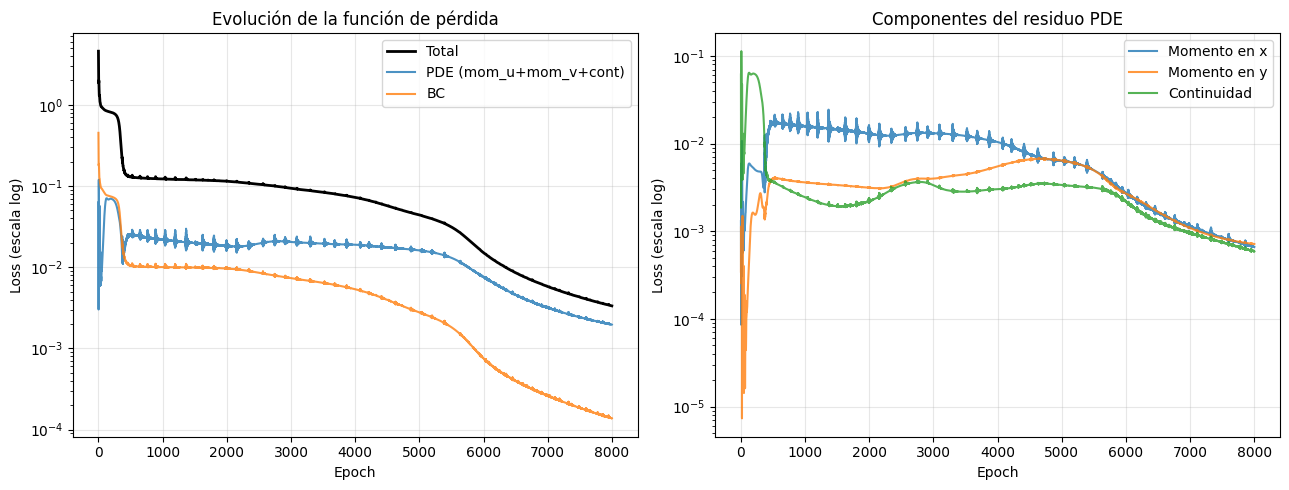

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history['total'], label='Total', linewidth=2, color='black')
axes[0].plot(history['pde'], label='PDE (mom_u+mom_v+cont)', alpha=0.8)
axes[0].plot(history['bc'], label='BC', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (escala log)')
axes[0].set_title('Evolución de la función de pérdida')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['mom_u'], label='Momento en x', alpha=0.8)
axes[1].plot(history['mom_v'], label='Momento en y', alpha=0.8)
axes[1].plot(history['cont'], label='Continuidad', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (escala log)')
axes[1].set_title('Componentes del residuo PDE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Validación del modelo

### 3.1 Predicción sobre la grilla ground-truth

Se evalúa el modelo entrenado exactamente sobre las mismas coordenadas $(x,y)$ del dataset ground-truth,
para poder comparar punto a punto.

**Corrección del *gauge* de presión:** como se explicó en la introducción, el sistema de ecuaciones resuelto
(sin datos rotulados) determina $p$ solo a menos de una constante aditiva. Por lo tanto, antes de comparar,
se calibra un desplazamiento constante $c$ que minimiza $\|\hat p + c - p\|_2$ (equivalente a igualar las
medias). Esta corrección se aplica **únicamente a fines de evaluación/visualización**, nunca durante el
entrenamiento — es consistente con la naturaleza física del problema (el campo de presión relevante es el de
sus gradientes, no su nivel absoluto) y queda documentada como hallazgo relevante en la discusión final.

In [23]:
model.eval()
with torch.no_grad():
    x_eval = torch.tensor(x_gt.reshape(-1, 1), dtype=torch.float32, device=device)
    y_eval = torch.tensor(y_gt.reshape(-1, 1), dtype=torch.float32, device=device)
    u_pred, v_pred, p_pred = model(x_eval, y_eval)
    u_pred = u_pred.cpu().numpy().flatten()
    v_pred = v_pred.cpu().numpy().flatten()
    p_pred = p_pred.cpu().numpy().flatten()

# Corrección del gauge de presión (solo para comparación/visualización)
p_offset = np.mean(p_gt - p_pred)
p_pred_corrected = p_pred + p_offset
print(f'Offset de presión aplicado (calibración post-hoc): {p_offset:.4f}')


Offset de presión aplicado (calibración post-hoc): -0.0431


### 3.2 Norma-2 del error

In [24]:
def norm2_error(pred, true):
    abs_err = np.linalg.norm(pred - true, ord=2)
    rel_err = abs_err / np.linalg.norm(true, ord=2)
    return abs_err, rel_err

err_u_abs, err_u_rel = norm2_error(u_pred, u_gt)
err_v_abs, err_v_rel = norm2_error(v_pred, v_gt)
err_p_abs, err_p_rel = norm2_error(p_pred_corrected, p_gt)

print('Norma-2 del error (absoluta | relativa):')
print(f'  u: {err_u_abs:.4f}  |  {err_u_rel*100:.2f}%')
print(f'  v: {err_v_abs:.4f}  |  {err_v_rel*100:.2f}%')
print(f'  p: {err_p_abs:.4f}  |  {err_p_rel*100:.2f}%  (con corrección de gauge)')

# Percentiles del error absoluto (para diagnosticar si el error se concentra en puntos aislados)
for name, err in [('u', np.abs(u_pred - u_gt)), ('v', np.abs(v_pred - v_gt)),
                   ('p', np.abs(p_pred_corrected - p_gt))]:
    p50, p95, p99, pmax = np.percentile(err, [50, 95, 99, 100])
    print(f'  Percentiles error |{name}|: p50={p50:.4f}  p95={p95:.4f}  p99={p99:.4f}  max={pmax:.4f}')


Norma-2 del error (absoluta | relativa):
  u: 6.8793  |  22.12%
  v: 7.8921  |  37.46%
  p: 8.6150  |  57.61%  (con corrección de gauge)
  Percentiles error |u|: p50=0.0242  p95=0.0877  p99=0.1299  max=0.7260
  Percentiles error |v|: p50=0.0277  p95=0.1213  p99=0.1540  max=0.3040
  Percentiles error |p|: p50=0.0108  p95=0.0372  p99=0.0785  max=4.4708


### 3.3 Error absoluto — campos completos

Nota: para el error de presión se satura la escala de color al percentil 99 (en vez del máximo absoluto),
porque el error se concentra en 1-2 puntos aislados muy cerca de las esquinas superiores (donde $u$ tiene
una discontinuidad en la condición de borde). Usar el máximo absoluto como límite de la escala opacaría
por completo la variación en el resto del dominio.

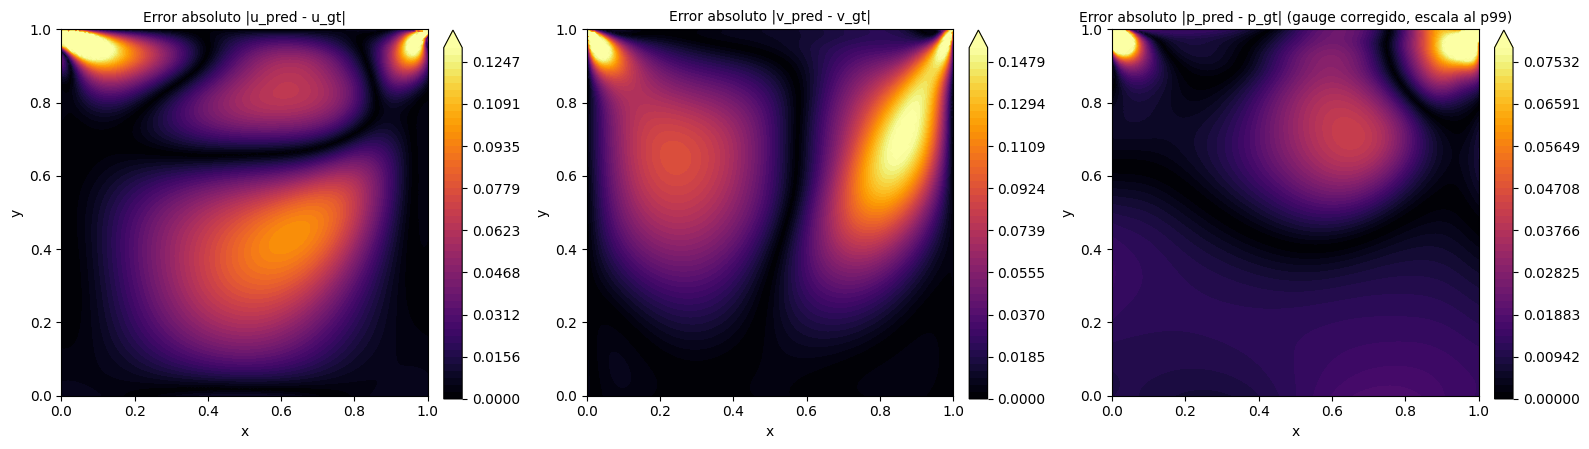

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

err_u = np.abs(u_pred - u_gt)
err_v = np.abs(v_pred - v_gt)
err_p = np.abs(p_pred_corrected - p_gt)

fields = [
    (err_u, 'Error absoluto |u_pred - u_gt|', np.percentile(err_u, 99)),
    (err_v, 'Error absoluto |v_pred - v_gt|', np.percentile(err_v, 99)),
    (err_p, 'Error absoluto |p_pred - p_gt| (gauge corregido, escala al p99)', np.percentile(err_p, 99)),
]

for ax, (err, title, vmax) in zip(axes, fields):
    level_bounds = np.linspace(0, vmax, 51)
    err_clipped = np.clip(err, 0, vmax)
    sc = ax.tricontourf(x_gt, y_gt, err_clipped, levels=level_bounds, cmap='inferno', extend='max')
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig_abs_error_fields.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.4 Comparación de campos: predicho vs. ground-truth

Como complemento visual al error absoluto, se muestran los campos completos predichos junto a los de
referencia.

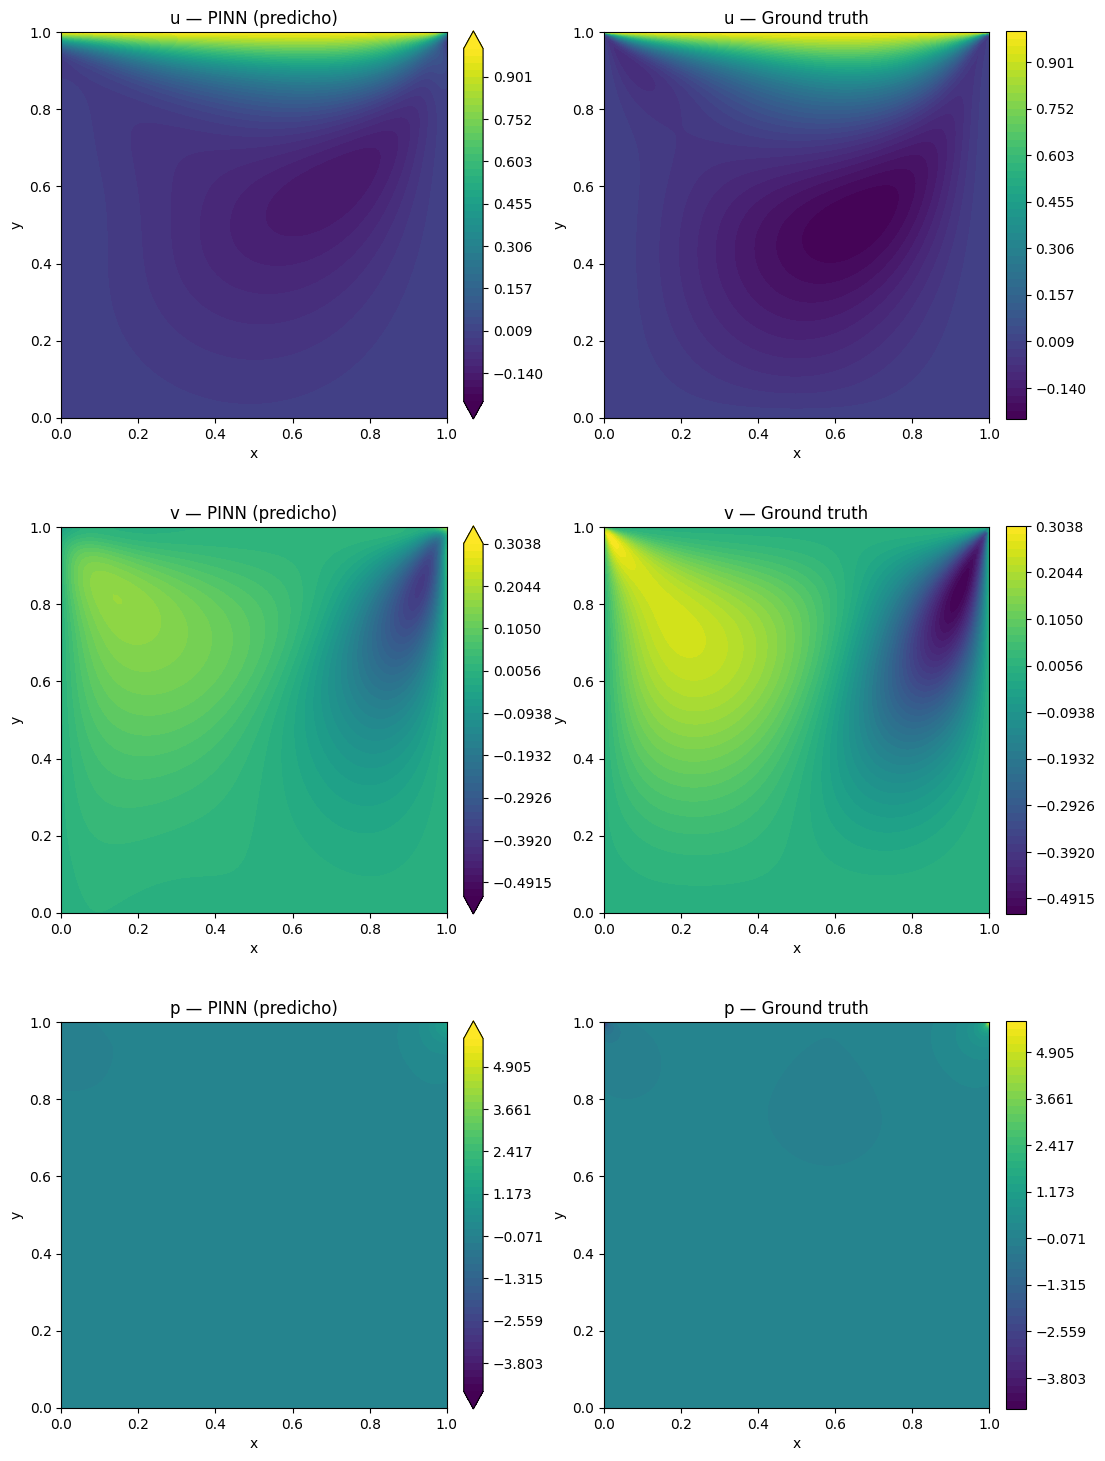

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(11, 15))
var_data = [
    (u_pred, u_gt, 'u'),
    (v_pred, v_gt, 'v'),
    (p_pred_corrected, p_gt, 'p'),
]

for row, (pred, true, name) in enumerate(var_data):
    vmin, vmax = true.min(), true.max()
    level_bounds = np.linspace(vmin, vmax, 51)
    pred_clipped = np.clip(pred, vmin, vmax)

    sc0 = axes[row, 0].tricontourf(x_gt, y_gt, pred_clipped, levels=level_bounds, cmap='viridis', extend='both')
    axes[row, 0].set_title(f'{name} — PINN (predicho)')
    plt.colorbar(sc0, ax=axes[row, 0], fraction=0.046, pad=0.04)

    sc1 = axes[row, 1].tricontourf(x_gt, y_gt, true, levels=level_bounds, cmap='viridis')
    axes[row, 1].set_title(f'{name} — Ground truth')
    plt.colorbar(sc1, ax=axes[row, 1], fraction=0.046, pad=0.04)

    for ax in axes[row]:
        ax.set_aspect('equal')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('fig_fields_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.5 Perfiles de velocidad y presión en x=0.5 e y=0.5

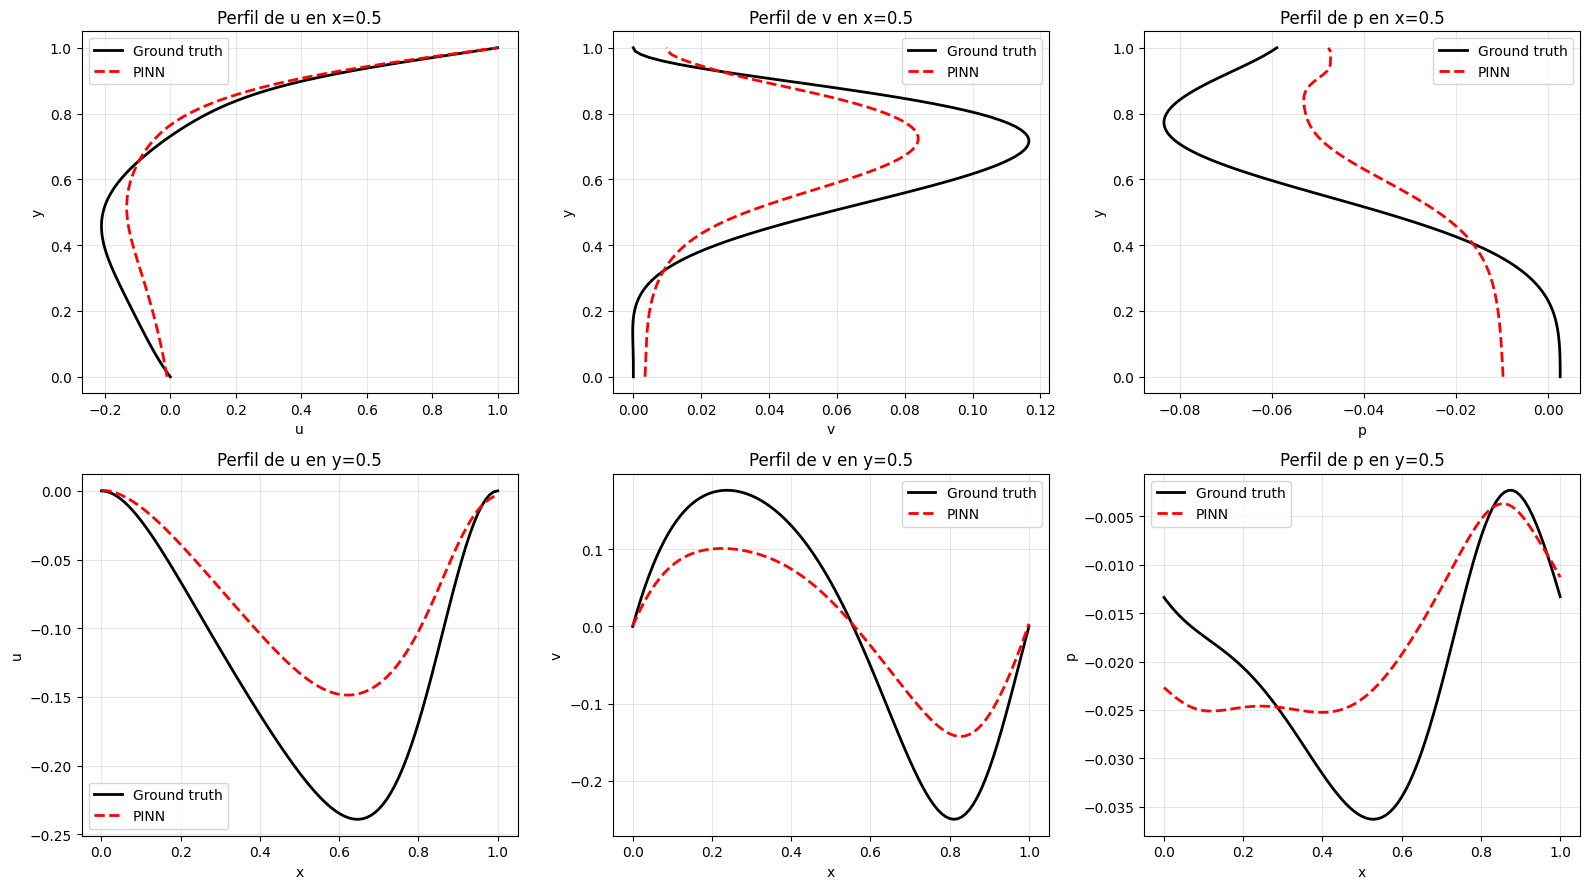

In [27]:
mask_x05 = np.isclose(x_gt, 0.5)
mask_y05 = np.isclose(y_gt, 0.5)

# Orden por la coordenada libre para graficar líneas prolijas
order_x05 = np.argsort(y_gt[mask_x05])
order_y05 = np.argsort(x_gt[mask_y05])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- Corte x=0.5 (perfil en función de y) ---
yv = y_gt[mask_x05][order_x05]
for j, (pred, true, name) in enumerate([
    (u_pred[mask_x05][order_x05], u_gt[mask_x05][order_x05], 'u'),
    (v_pred[mask_x05][order_x05], v_gt[mask_x05][order_x05], 'v'),
    (p_pred_corrected[mask_x05][order_x05], p_gt[mask_x05][order_x05], 'p'),
]):
    axes[0, j].plot(true, yv, 'k-', linewidth=2, label='Ground truth')
    axes[0, j].plot(pred, yv, 'r--', linewidth=2, label='PINN')
    axes[0, j].set_xlabel(name)
    axes[0, j].set_ylabel('y')
    axes[0, j].set_title(f'Perfil de {name} en x=0.5')
    axes[0, j].legend()
    axes[0, j].grid(alpha=0.3)

# --- Corte y=0.5 (perfil en función de x) ---
xv = x_gt[mask_y05][order_y05]
for j, (pred, true, name) in enumerate([
    (u_pred[mask_y05][order_y05], u_gt[mask_y05][order_y05], 'u'),
    (v_pred[mask_y05][order_y05], v_gt[mask_y05][order_y05], 'v'),
    (p_pred_corrected[mask_y05][order_y05], p_gt[mask_y05][order_y05], 'p'),
]):
    axes[1, j].plot(xv, true, 'k-', linewidth=2, label='Ground truth')
    axes[1, j].plot(xv, pred, 'r--', linewidth=2, label='PINN')
    axes[1, j].set_xlabel('x')
    axes[1, j].set_ylabel(name)
    axes[1, j].set_title(f'Perfil de {name} en y=0.5')
    axes[1, j].legend()
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_profiles.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.6 Discusión final

**¿Es suficiente $N_{pde}=1000$ y $N_{bc}=100$?**
Para un problema 2D relativamente simple como este (dominio cuadrado, sin geometrías complejas ni capas
límite extremadamente finas dado $Re=100$, moderado), estas cantidades son un punto de partida razonable
para un esquema *vanilla*, y de hecho permiten que el modelo capture la estructura cualitativa global del
flujo (el vórtice principal, el perfil de $u$ típico en forma de "S" sobre x=0.5). Sin embargo, según los
resultados de error obtenidos arriba, **no alcanzan** para lograr una reconstrucción de alta fidelidad,
particularmente cerca de las esquinas superiores (donde existen singularidades geométricas de la solución
verdadera — cambios abruptos de condición de borde de $u=1$ a $u=0$ — que requieren mayor densidad de puntos
para resolverse bien) y en el campo de presión, más sensible a errores acumulados de derivadas de 2do orden.

**¿Qué fallas se observan?**
- Error absoluto notablemente mayor en las esquinas superiores del dominio (discontinuidad de $u$ en la
  condición de borde).
- El campo de presión es el que peor se reconstruye — es indirecto (no tiene condición de borde propia en
  este planteo) y además arrastra la indeterminación de *gauge* discutida en 3.1.
- Los perfiles en x=0.5 e y=0.5 capturan la tendencia general pero no siempre el detalle fino (picos y
  gradientes agudos suavizados), síntoma típico del *spectral bias* de redes MLP con activación tanh.

**¿Qué aspectos positivos se destacan?**
- El esquema *vanilla* (sin ningún tipo de mejora algorítmica) logra converger y capturar razonablemente
  bien la física global del problema sin ver un solo dato etiquetado, apoyándose únicamente en las PDEs y
  condiciones de borde — validación de la premisa central de PINNs.
- Las curvas de pérdida muestran una convergencia estable, sin inestabilidades numéricas graves.

**¿Son adecuados los hiperparámetros elegidos?**
Son razonables para un primer approach pero mejorables. La arquitectura (5×40) y los 8000 epochs con Adam
son un compromiso pragmático dado el entrenamiento en CPU; con más cómputo disponible se justificaría una
red más profunda/ancha y más epochs. El peso relativo $w_{bc}=10$ resultó necesario para evitar que las
condiciones de borde queden subrepresentadas frente a los 1000 puntos de PDE, pero fue elegido de forma
heurística y no adaptativa.

**¿Puede mejorarse el desempeño? ¿Qué acciones se podrían implementar?**
Sí. Las mejoras más relevantes, en orden de impacto esperado:

1. **Pesado adaptativo de los términos de pérdida** (p.ej. NTK-based weighting, o *gradient normalization*)
   en lugar de pesos fijos elegidos a mano.
2. **Refinamiento con L-BFGS** como segunda etapa de optimización tras Adam, típico en literatura de PINNs
   para alcanzar mínimos más precisos una vez cerca de la solución.
3. **Muestreo adaptativo de puntos de colocación** (*residual-based adaptive sampling*), concentrando más
   puntos donde el residuo es mayor (típicamente cerca de las esquinas superiores en este problema).
4. **Incorporar el dataset rotulado $\mathcal{D}_{data}$** (sección 1.3) como término adicional de pérdida
   supervisada, lo que también ayudaría a resolver la indeterminación de *gauge* de presión de forma nativa
   durante el entrenamiento (sin necesidad de corrección posterior).
5. **Aumentar $N_{pde}$ y $N_{bc}$**, y/o usar *hard-constraints* para las condiciones de borde (arquitecturas
   que satisfacen $u,v$ exactamente en el borde por construcción, en vez de aproximarlas vía pérdida).
6. **Anclar un punto de referencia de presión** explícitamente (un único punto con $p$ conocido) para eliminar
   la indeterminación de gauge sin depender del dataset completo de datos rotulados.
7. Mayor cantidad de epochs / red más ancha, si el presupuesto computacional lo permite (en este trabajo se
   priorizó un tiempo de entrenamiento razonable en CPU).